In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import residue
from scipy.linalg import matmul_toeplitz
from tqdm import tqdm
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import minimize_scalar

# FUNCTIONS

In [3]:
# ==========================================
# 1. HELPER FUNCTIONS & INVERSE LAPLACE
# ==========================================
def coth(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)

    r = np.real(z)

    pos = r > 20
    neg = r < -20
    mid = ~(pos | neg)

    out[pos] = 1.0 + 2*np.exp(-2*z[pos])
    out[neg] = -1.0 - 2*np.exp(2*z[neg])
    out[mid] = np.cosh(z[mid])/np.sinh(z[mid])

    return out.item() if out.ndim == 0 else out


def csch2(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)

    r = np.real(z)

    large = np.abs(r) > 20
    small = ~large

    out[large] = 4*np.exp(-2*np.abs(r[large]))*np.exp(-2j*np.imag(z[large])*0)

    s = np.sinh(z[small])
    out[small] = 1/(s*s)

    return out.item() if out.ndim == 0 else out

def inverse_laplace_rational(B, A, enforce_real=True):
    B = np.atleast_1d(np.array(B, dtype=np.complex128))
    A = np.atleast_1d(np.array(A, dtype=np.complex128))
    r, p, k = residue(B, A)

    info = {"residues": r, "poles": p, "direct_poly": k}
    return info

def derivatives_from_residues(t, residues, poles, enforce_real=True):
    t = np.asarray(t, dtype=float)

    G    = np.zeros_like(t, dtype=np.complex128)
    Gdot = np.zeros_like(t, dtype=np.complex128)
    Gddot= np.zeros_like(t, dtype=np.complex128)

    for r, p in zip(residues, poles):
        ep = np.exp(p * t)
        G     += r * ep
        Gdot  += r * p * ep
        Gddot += r * p * p * ep

    if enforce_real:
        G     = np.real_if_close(G)
        Gdot  = np.real_if_close(Gdot)
        Gddot = np.real_if_close(Gddot)

    return G, Gdot, Gddot

# ==========================================
# 2. NOISE KERNEL & TEMPERATURE DERIVATIVE
# ==========================================
def noise_kernel_residue(t, gamma, alpha1, alpha2, Temp, Nmats=30000, delta_eps=1e-10):
    scalar_input = np.isscalar(t)
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.abs(t)
    
    Delta = 4.0 * alpha2 * gamma - gamma**2
    beta = 1.0 / Temp
    a = 0.5 * beta

    if abs(Delta) < delta_eps:
        w0 = 0.5j * gamma
        exp0 = np.exp(1j * w0 * t)
        coth0 = coth(a * w0)
        fprime = (a * (-csch2(a * w0)) + 1j * t * coth0) * exp0
        nu_sys = (np.pi * gamma * alpha1 * alpha2 / 2.0) * np.real(fprime)
    else:
        sqrtDelta = np.sqrt(Delta + 0j)  
        w_plus  = 0.5j * gamma + 0.5 * sqrtDelta
        w_minus = 0.5j * gamma - 0.5 * sqrtDelta
        term_plus  = coth(a * w_plus)  * np.exp(1j * w_plus  * t)
        term_minus = coth(a * w_minus) * np.exp(1j * w_minus * t)
        pref = ( gamma * alpha1 * alpha2) / (2.0 * sqrtDelta)
        nu_sys = np.real(pref * (term_plus - term_minus))

    n = np.arange(1, Nmats+1, dtype=np.float64)
    nu_n = (2.0 * np.pi / beta) * n
    denom = (alpha2 * gamma + nu_n**2)**2 - (gamma * nu_n)**2
    expo = np.exp(-nu_n[:, None] * t[None, :])
    mats_sum = (nu_n / denom)[:, None] * expo
    nu_M = -(2.0  * gamma**2 * alpha1 * alpha2 / beta) * mats_sum.sum(axis=0)

    out = (nu_sys + nu_M)
    return float(out[0]) if scalar_input else out

def dnu_dT_residue(t, gamma, alpha1, alpha2, Temp, Nmats=30000, delta_eps=1e-10):
    scalar_input = np.isscalar(t)
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    t = np.abs(t)
    
    Delta = 4.0 * alpha2 * gamma - gamma**2
    beta = 1.0 / Temp
    T2 = Temp**2

    if abs(Delta) < delta_eps:
        w0 = 0.5j * gamma
        a = 0.5 * beta
        exp0 = np.exp(1j * w0 * t)
        nu_sys_deriv = (np.pi * gamma * alpha1 * alpha2 / (4.0 * T2)) * np.real(w0 * csch2(a * w0) * exp0) 
    else:
        sqrtDelta = np.sqrt(Delta + 0j)  
        w_plus  = 0.5j * gamma + 0.5 * sqrtDelta
        w_minus = 0.5j * gamma - 0.5 * sqrtDelta
        term_plus  = w_plus * csch2(0.5 * beta * w_plus) * np.exp(1j * w_plus * t)
        term_minus = w_minus * csch2(0.5 * beta * w_minus) * np.exp(1j * w_minus * t)
        pref = -(gamma * alpha1 * alpha2) / (4.0 * T2 * sqrtDelta)
        nu_sys_deriv = np.real(pref * (term_plus - term_minus))

    k = np.arange(1, Nmats + 1, dtype=np.float64)
    fk = (2.0 * np.pi / beta) * k
    
    denom = (alpha2 * gamma + fk**2)**2 - (gamma * fk)**2
    expo = np.exp(-fk[:, None] * t[None, :])
    
    term_A_sum = (fk[:, None] / denom[:, None]) * expo
    term_A = - (2.0 * gamma**2 * alpha1 * alpha2) * term_A_sum.sum(axis=0)
    
    num_part1 = expo * (1 - t[None, :] * fk[:, None]) * denom[:, None]

    # Calculate the purely k-dependent polynomial in 1D first
    inner_k_term = 4 * fk * (alpha2 * gamma + fk**2) - 2 * gamma**2 * fk

    # Then broadcast it against the time-dependent expo matrix
    num_part2 = fk[:, None] * expo * inner_k_term[:, None]
    term_B_sum = k[:, None] * ((num_part1 - num_part2) / (denom[:, None]**2))
    term_B = - (4.0 * np.pi * gamma**2 * alpha1 * alpha2 / beta) * term_B_sum.sum(axis=0)

    nu_M_deriv = term_A + term_B
    out = nu_sys_deriv + nu_M_deriv
    
    return float(out[0]) if scalar_input else out


def find_precise_peak(time_array, rate_array, window_size=3):
    """
    Finds the sub-grid maximum of a rate array using cubic spline interpolation
    and bounded optimization.
    Returns: (t_opt, max_rate)
    """
    # 1. Find the discrete maximum index
    max_idx = np.argmax(rate_array)
    '''
    # Handle edge cases (if peak is at the very boundary)
    start_idx = max(0, max_idx - window_size)
    end_idx = min(len(time_array), max_idx + window_size + 1)
        
    # 2. Extract the local window
    t_window = time_array[start_idx:end_idx]
    r_window = rate_array[start_idx:end_idx]
    
    # Ensure enough points for a cubic spline
    if len(t_window) < 4:
        return time_array[max_idx], rate_array[max_idx]

    # 3. Fit a cubic spline (k=3)
    spline = InterpolatedUnivariateSpline(t_window, r_window, k=3)
    
    # 4. Find the peak using bounded optimization on the inverted spline
    res = minimize_scalar(lambda t: -spline(t), 
                          bounds=(t_window[0], t_window[-1]), 
                          method='bounded')
    
    if res.success:
        t_opt = res.x
        max_rate = float(-res.fun)
    else:
        # Fallback if optimization fails
        t_opt = time_array[max_idx]
        max_rate = rate_array[max_idx]
    '''

    t_opt = time_array[max_idx]
    max_rate = rate_array[max_idx]
        
    return t_opt, max_rate



# Optimal Time vs Squeezing Angle

Pre-computing bath memory and Green's functions...
Sweeping Squeezing Angle (r=0.01, T=0.01)...


Angle Sweep:   0%|          | 0/100 [00:00<?, ?it/s]

Angle Sweep: 100%|██████████| 100/100 [14:53<00:00,  8.94s/it]


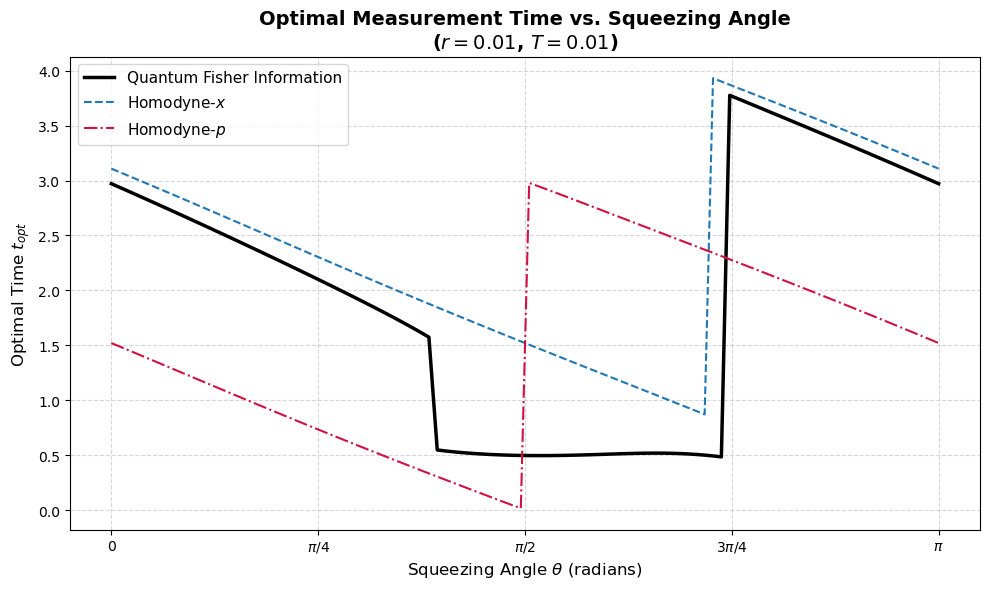


=> Absolute Maximum t_opt for QFI found at theta = 2.348 rad (134.5 degrees)
=> Maximum t_opt = 3.7754


In [25]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]])
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]])

    # Symplectic Matrix for QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # 3. Quantum FI
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25*kron_omega
        evals, evecs = np.linalg.eigh(M)
        threshold = 1e-12
        evals_inv = np.where(evals > threshold, 1.0 / evals, 0.0)
        M_inv = evecs @ np.diag(evals_inv) @ evecs.T
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
        
        # 4. Calculate Rates directly
        t_current = t_array[i]
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }


if __name__ == "__main__":
 
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    
    temp = 0.01 
    mass = 1.0
    
    r_fixed = 0.01 
    
    # Dense angle grid (0 to pi is a full rotation for an ellipse)
    num_angles = 100
    thetas = np.linspace(0, np.pi, num_angles)
    
    # Time array for the dynamics
    times = np.linspace(0, 10, 2500)
    
    # 2. Pre-compute Bath Dynamics (Run ONCE)
    print("Pre-computing bath memory and Green's functions...")
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    # 3. Sweep the Angle
    x0, p0 = 0.0, 0.0
    
    # Storage for optimal times
    t_opt_QFI = np.zeros(num_angles)
    t_opt_hom_x = np.zeros(num_angles)
    t_opt_hom_p = np.zeros(num_angles)
    
    print(f"Sweeping Squeezing Angle (r={r_fixed}, T={temp})...")
    
    for i, theta in enumerate(tqdm(thetas, desc="Angle Sweep")):
        # Generate the rotated state
        sigma0 = generate_sigma0(r_fixed, theta)
        
        # Evolve dynamics (bath part is basically free now)
        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        
        # Extract sub-grid optimal times (skipping t=0 to avoid div-by-zero rates)
        valid_times = sol["time"][1:]
        
        t_opt_QFI[i], _ = find_precise_peak(valid_times, sol["rate_QFI"][1:])
        t_opt_hom_x[i], _ = find_precise_peak(valid_times, sol["rate_hom_x"][1:])
        t_opt_hom_p[i], _ = find_precise_peak(valid_times, sol["rate_hom_p"][1:])

    # 4. Visualize the Magic Angles
    plt.figure(figsize=(10, 6))
    
    plt.plot(thetas, t_opt_QFI, label="Quantum Fisher Information", color='black', linewidth=2.5)
    plt.plot(thetas, t_opt_hom_x, label="Homodyne-$x$", color='#1f77b4', linestyle='--')
    plt.plot(thetas, t_opt_hom_p, label="Homodyne-$p$", color='#d11141', linestyle='-.')
    
    plt.title(f"Optimal Measurement Time vs. Squeezing Angle\n($r={r_fixed}$, $T={temp}$)", fontsize=14, fontweight='bold')
    plt.xlabel(r"Squeezing Angle $\theta$ (radians)", fontsize=12)
    plt.ylabel(r"Optimal Time $t_{opt}$", fontsize=12)
    
    # Highlight the axes
    plt.xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], 
               ['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
    
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(loc='best', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # 5. Output the best angle for QFI
    best_idx = np.argmax(t_opt_QFI)
    best_theta = thetas[best_idx]
    best_time = t_opt_QFI[best_idx]
    print(f"\n=> Absolute Maximum t_opt for QFI found at theta = {best_theta:.3f} rad ({best_theta*180/np.pi:.1f} degrees)")
    print(f"=> Maximum t_opt = {best_time:.4f}")

# Max FI Rate vs Squeezing Angle

Pre-computing bath memory and Green's functions...
Sweeping Squeezing Angle for max FI Rate (r=1000, T=0.01)...


Angle Sweep: 100%|██████████| 100/100 [05:20<00:00,  3.20s/it]


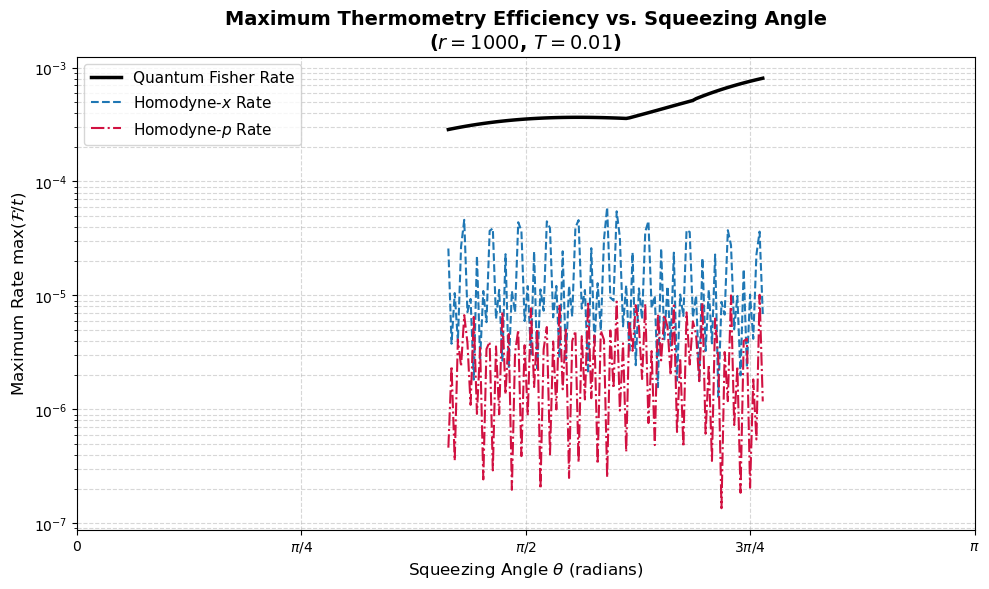


=> Absolute Maximum Efficiency for QFI found at theta = 2.400 rad (137.5 degrees)
=> Maximum Rate = 8.0608e-04


In [28]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]])
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]])

    # Symplectic Matrix for QFI
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # 3. Quantum FI
        kron_sigma = np.kron(sigma_t, sigma_t)
        M = kron_sigma - 0.25*kron_omega
        evals, evecs = np.linalg.eigh(M)
        threshold = 1e-12
        evals_inv = np.where(evals > threshold, 1.0 / evals, 0.0)
        M_inv = evecs @ np.diag(evals_inv) @ evecs.T
        
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI[i] = 0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))
        
        # 4. Calculate Rates directly
        t_current = t_array[i]
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }


if __name__ == "__main__":
    # 1. System and Bath Parameters (Fixed)
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    
    temp = 0.01 
    mass = 1.0
    
    # Fix the magnitude of squeezing (e.g., highly position-squeezed)
    r_fixed = 1000 
    
    # Dense angle grid
    num_angles = 100 # Increased slightly for a smoother curve
    thetas = np.linspace(1.3, 2.4, num_angles)
    
    times = np.linspace(0, 50, 1000)
    
    # 2. Pre-compute Bath Dynamics
    print("Pre-computing bath memory and Green's functions...")
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    # 3. Sweep the Angle
    x0, p0 = 0.0, 0.0
    
    # Storage for Maximum Rates
    max_rate_QFI = np.zeros(num_angles)
    max_rate_hom_x = np.zeros(num_angles)
    max_rate_hom_p = np.zeros(num_angles)
    
    print(f"Sweeping Squeezing Angle for max FI Rate (r={r_fixed}, T={temp})...")
    
    for i, theta in enumerate(tqdm(thetas, desc="Angle Sweep")):
        sigma0 = generate_sigma0(r_fixed, theta)
        
        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        valid_times = sol["time"][1:]
        
        # Extract both time and rate, but we only store the rate here
        _, max_rate_QFI[i] = find_precise_peak(valid_times, sol["rate_QFI"][1:])
        _, max_rate_hom_x[i] = find_precise_peak(valid_times, sol["rate_hom_x"][1:])
        _, max_rate_hom_p[i] = find_precise_peak(valid_times, sol["rate_hom_p"][1:])

    # 4. Visualize the Maximum Protocol Efficiency
    plt.figure(figsize=(10, 6))
    
    plt.plot(thetas, max_rate_QFI, label="Quantum Fisher Rate", color='black', linewidth=2.5)
    plt.plot(thetas, max_rate_hom_x, label="Homodyne-$x$ Rate", color='#1f77b4', linestyle='--')
    plt.plot(thetas, max_rate_hom_p, label="Homodyne-$p$ Rate", color='#d11141', linestyle='-.')
    
    plt.title(f"Maximum Thermometry Efficiency vs. Squeezing Angle\n($r={r_fixed}$, $T={temp}$)", fontsize=14, fontweight='bold')
    plt.xlabel(r"Squeezing Angle $\theta$ (radians)", fontsize=12)
    plt.ylabel(r"Maximum Rate $\max(\mathcal{F}/t)$", fontsize=12)
    plt.yscale('log') # Log scale is usually best for FI rates as they span orders of magnitude
    
    plt.xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], 
               ['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
    
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(loc='best', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # 5. Output the best angle for highest precision
    best_idx = np.argmax(max_rate_QFI)
    best_theta = thetas[best_idx]
    best_rate = max_rate_QFI[best_idx]
    print(f"\n=> Absolute Maximum Efficiency for QFI found at theta = {best_theta:.3f} rad ({best_theta*180/np.pi:.1f} degrees)")
    print(f"=> Maximum Rate = {best_rate:.4e}")

# Max Rate & t_opt vs Squeezing Magnitude

Pre-computing bath memory and Green's functions...
Sweeping Squeezing Magnitude r (T=0.5)...


Magnitude Sweep: 100%|██████████| 200/200 [1:38:08<00:00, 29.44s/it]


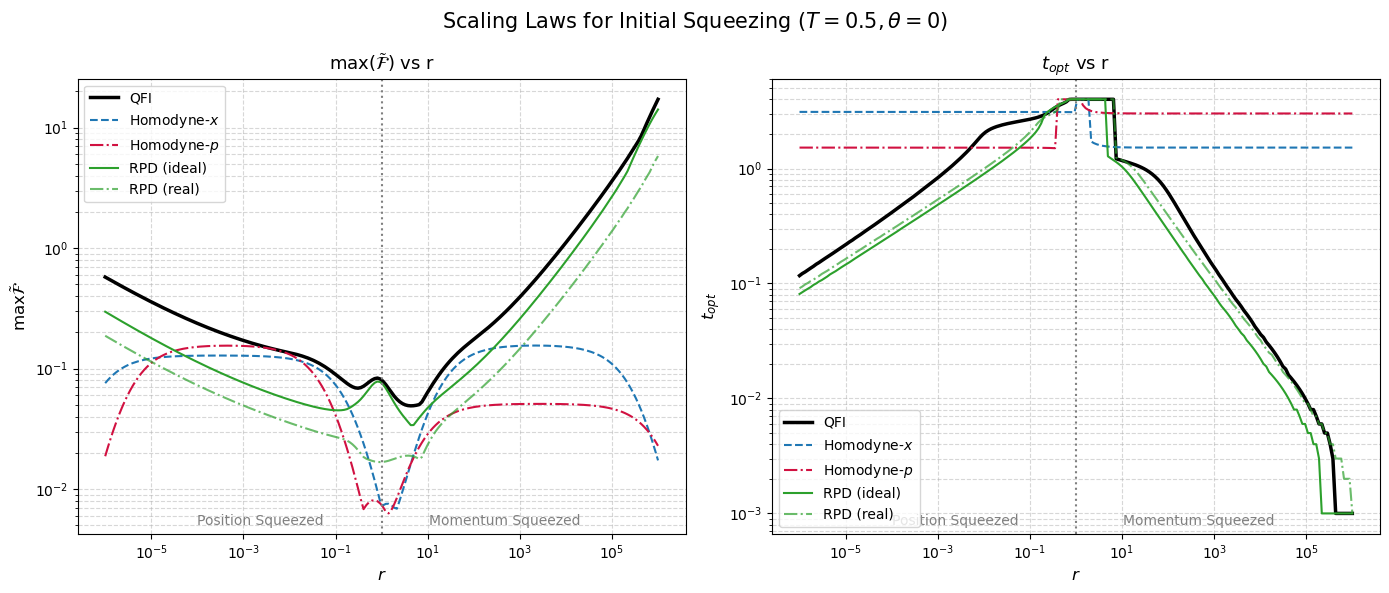

In [8]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-9, 0.0], [0.0, 1e9]])
    sig_M_hom_p = np.array([[1e9, 0.0], [0.0, 1e-9]])
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        t_current = t_array[i]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)

        # --- 2. Active Photodetection FIs (Ideal & Realistic) ---
        # --- DYNAMIC ADAPTATION ---
        # 1. Calculate the free rotation angle at the current time
        phase = Omega_S * t_current
        c_rot = np.cos(phase)
        s_rot = np.sin(phase)
        
        # 2. Build the symplectic rotation matrix for the free oscillator
        S_rot = np.array([
            [c_rot,              s_rot / Omega_S],
            [-Omega_S * s_rot,   c_rot          ]
        ])
        
        # 3. Rotate the measurement basis to track the state
        sigma_M_adaptive = S_rot @ sigma0 @ S_rot.T
        
        # 4. Use the adaptive matrix for photodetection
        A_rpd = sigma_t + sigma_M_adaptive
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal Active RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic Active RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.15) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)
        

        # --- 3. Quantum FI (Using Analytical Formula from Appendix B) ---
        
        # 3.a) Calculate determinants explicitly for 2x2 matrices
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        
        # 3.b) Calculate the temperature derivative of the determinant (Eq. B15)
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        # 3.c) Apply Eq. (B20)
        # We use a tiny epsilon max-gate to prevent strict ZeroDivision at exactly t=0
        # since det_sigma approaches 0.25 for pure states.
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        # 4. Calculate Rates directly
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }




if __name__ == "__main__":
    # 1. System and Bath Parameters
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    
    temp = 0.5 
    mass = 1.0
    
    # 2. Logarithmic Squeezing Grid (r from 10^-3 to 10^3)
    num_r = 200
    r_values = np.logspace(-6, 6, num_r)
    
    times = np.linspace(0, 4, 4000)
    
    # 3. Pre-compute Bath Dynamics
    print("Pre-computing bath memory and Green's functions...")
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    info = inverse_laplace_rational(B, A)
    G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
    Gdot = Gprime_of_t
    
    # Storage arrays
    max_rate_QFI, t_opt_QFI = np.zeros(num_r), np.zeros(num_r)
    max_rate_hom_x, t_opt_hom_x = np.zeros(num_r), np.zeros(num_r)
    max_rate_hom_p, t_opt_hom_p = np.zeros(num_r), np.zeros(num_r)
    max_rate_rpd_ideal, t_opt_rpd_ideal = np.zeros(num_r), np.zeros(num_r)
    max_rate_rpd_real, t_opt_rpd_real = np.zeros(num_r), np.zeros(num_r)
    
    print(f"Sweeping Squeezing Magnitude r (T={temp})...")
    
    # 4. Sweep r
    x0, p0 = 0.0, 0.0
    for i, r in enumerate(tqdm(r_values, desc="Magnitude Sweep")):
        # Pragmatic path: strictly diagonal matrix (theta = 0)
        sigma0 = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
        
        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        valid_times = sol["time"][1:]
        
        t_opt_QFI[i], max_rate_QFI[i] = find_precise_peak(valid_times, sol["rate_QFI"][1:])
        t_opt_hom_x[i], max_rate_hom_x[i] = find_precise_peak(valid_times, sol["rate_hom_x"][1:])
        t_opt_hom_p[i], max_rate_hom_p[i] = find_precise_peak(valid_times, sol["rate_hom_p"][1:])
        t_opt_rpd_real[i], max_rate_rpd_real[i] = find_precise_peak(valid_times, sol["rate_rpd_real"][1:])
        t_opt_rpd_ideal[i], max_rate_rpd_ideal[i] = find_precise_peak(valid_times, sol["rate_rpd_ideal"][1:])

    # 5. Visualize the Scaling Laws
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Panel 1: Peak Rate vs r ---
    ax1.plot(r_values, max_rate_QFI, label="QFI", color='black', linewidth=2.5)
    ax1.plot(r_values, max_rate_hom_x, label="Homodyne-$x$", color='#1f77b4', linestyle='--')
    ax1.plot(r_values, max_rate_hom_p, label="Homodyne-$p$", color='#d11141', linestyle='-.')
    ax1.plot(r_values, max_rate_rpd_ideal, label="RPD (ideal)", color='#2ca02c')
    ax1.plot(r_values, max_rate_rpd_real, label="RPD (real)", color='#2ca02c',
            linestyle='-.', alpha=0.7)

    ax1.set_title(r"$\max(\mathcal{\tilde{F}})$ vs r", fontsize=13)
    ax1.set_xlabel("$r$", fontsize=12)
    ax1.set_ylabel(r"$\max\mathcal{\tilde{F}}$", fontsize=12)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend()
    
    # --- Panel 2: Optimal Time vs r ---
    ax2.plot(r_values, t_opt_QFI, label="QFI", color='black', linewidth=2.5)
    ax2.plot(r_values, t_opt_hom_x, label="Homodyne-$x$", color='#1f77b4', linestyle='--')
    ax2.plot(r_values, t_opt_hom_p, label="Homodyne-$p$", color='#d11141', linestyle='-.')
    ax2.plot(r_values, t_opt_rpd_ideal, label="RPD (ideal)", color='#2ca02c')
    ax2.plot(r_values, t_opt_rpd_real, label="RPD (real)", color='#2ca02c',
            linestyle='-.', alpha=0.7)

    ax2.set_title("$t_{opt}$ vs r", fontsize=13)
    ax2.set_xlabel("$r$", fontsize=12)
    ax2.set_ylabel("$t_{opt}$", fontsize=12)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend()
    
    # Add a visual divider for position vs momentum squeezing
    for ax in [ax1, ax2]:
        ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1.5)
        ax.text(0.0001, 0.02, 'Position Squeezed', transform=ax.get_xaxis_transform(), fontsize=10, color='gray')
        ax.text(10.5, 0.02, 'Momentum Squeezed', transform=ax.get_xaxis_transform(), fontsize=10, color='gray')

    plt.suptitle(rf"Scaling Laws for Initial Squeezing ($T={temp}, \theta=0$)", fontsize=15, y=0.98)
    plt.tight_layout()
    plt.show()

# Max Rate vs Coupling Strength

Sweeping Coupling Strength alpha1 (r=1, T=0.05)...


Coupling Sweep: 100%|██████████| 20/20 [1:17:00<00:00, 231.01s/it]


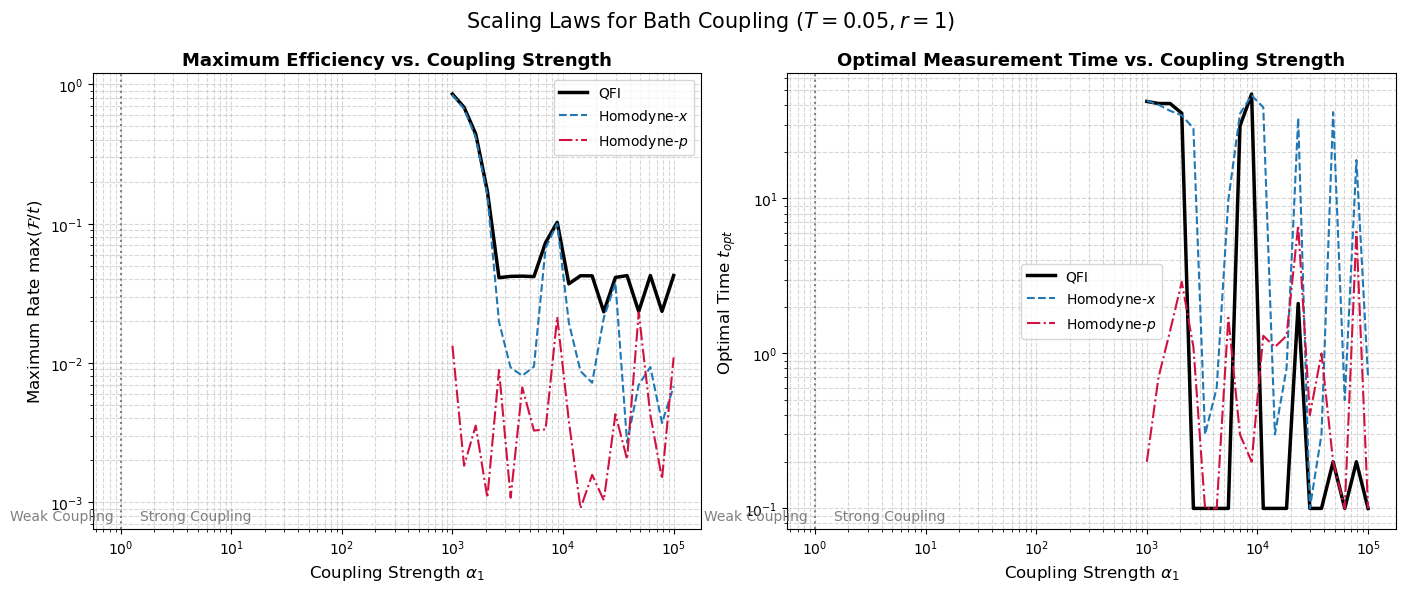

In [7]:
def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]])
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]])
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        t_current = t_array[i]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # --- 3. Quantum FI (Using Analytical Formula from Appendix B) ---
                
        # 3.a) Calculate determinants explicitly for 2x2 matrices
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        
        # 3.b) Calculate the temperature derivative of the determinant (Eq. B15)
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        # 3.c) Apply Eq. (B20)
        # We use a tiny epsilon max-gate to prevent strict ZeroDivision at exactly t=0
        # since det_sigma approaches 0.25 for pure states.
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        # 4. Calculate Rates directly
        
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }


if __name__ == "__main__":
    # 1. Fixed System and Bath Parameters
    gamma = 1.0
    alpha2 = 2.0
    Omega_S_bare = 1.0
    
    temp = 0.05 
    mass = 1.0
    
    # Lock in the optimal position-squeezed state
    r_fixed = 1
    sigma0 = 0.5 * np.array([[r_fixed, 0], 
                             [0, 1.0/r_fixed]])
    x0, p0 = 0.0, 0.0
    
    # 2. Logarithmic Coupling Grid (alpha1 from 10^-3 to 10^1)
    num_alpha1 = 20
    alpha1_values = np.logspace(3, 5, num_alpha1)
    
    times = np.linspace(0, 1000, 10000)
    
    # Storage arrays
    max_rate_QFI, t_opt_QFI = np.zeros(num_alpha1), np.zeros(num_alpha1)
    max_rate_hom_x, t_opt_hom_x = np.zeros(num_alpha1), np.zeros(num_alpha1)
    max_rate_hom_p, t_opt_hom_p = np.zeros(num_alpha1), np.zeros(num_alpha1)
    
    print(f"Sweeping Coupling Strength alpha1 (r={r_fixed}, T={temp})...")
    
    # 3. Sweep alpha1
    for i, alpha1 in enumerate(tqdm(alpha1_values, desc="Coupling Sweep")):
        
        # --- CRITICAL CHANGE: Recalculate Omega_S and bath dynamics ---
        delta_Omega_s = np.sqrt(alpha1)
        Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
        
        B = [1, gamma, alpha2 * gamma]
        A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
        
        info = inverse_laplace_rational(B, A)
        G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
        Gdot = Gprime_of_t
        # ----------------------------------------------------------------
        
        # Evolve dynamics
        sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
        valid_times = sol["time"][1:]
        
        # Extract precise peaks
        t_opt_QFI[i], max_rate_QFI[i] = find_precise_peak(valid_times, sol["rate_QFI"][1:])
        t_opt_hom_x[i], max_rate_hom_x[i] = find_precise_peak(valid_times, sol["rate_hom_x"][1:])
        t_opt_hom_p[i], max_rate_hom_p[i] = find_precise_peak(valid_times, sol["rate_hom_p"][1:])

    # 4. Visualize the Scaling Laws for Coupling
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Panel 1: Peak Rate vs alpha1 ---
    ax1.plot(alpha1_values, max_rate_QFI, label="QFI", color='black', linewidth=2.5)
    ax1.plot(alpha1_values, max_rate_hom_x, label="Homodyne-$x$", color='#1f77b4', linestyle='--')
    ax1.plot(alpha1_values, max_rate_hom_p, label="Homodyne-$p$", color='#d11141', linestyle='-.')
    
    ax1.set_title("Maximum Efficiency vs. Coupling Strength", fontsize=13, fontweight='bold')
    ax1.set_xlabel(r"Coupling Strength $\alpha_1$", fontsize=12)
    ax1.set_ylabel(r"Maximum Rate $\max(\mathcal{F}/t)$", fontsize=12)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend()
    
    # --- Panel 2: Optimal Time vs alpha1 ---
    ax2.plot(alpha1_values, t_opt_QFI, label="QFI", color='black', linewidth=2.5)
    ax2.plot(alpha1_values, t_opt_hom_x, label="Homodyne-$x$", color='#1f77b4', linestyle='--')
    ax2.plot(alpha1_values, t_opt_hom_p, label="Homodyne-$p$", color='#d11141', linestyle='-.')
    
    ax2.set_title("Optimal Measurement Time vs. Coupling Strength", fontsize=13, fontweight='bold')
    ax2.set_xlabel(r"Coupling Strength $\alpha_1$", fontsize=12)
    ax2.set_ylabel("Optimal Time $t_{opt}$", fontsize=12)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend()
    
    # Add a visual divider for weak vs strong coupling (at alpha1 = Omega_S_bare^2)
    for ax in [ax1, ax2]:
        ax.axvline(x=Omega_S_bare**2, color='gray', linestyle=':', linewidth=1.5)
        ax.text(Omega_S_bare**2 * 0.1, 0.02, 'Weak Coupling', transform=ax.get_xaxis_transform(), fontsize=10, color='gray')
        ax.text(Omega_S_bare**2 * 1.5, 0.02, 'Strong Coupling', transform=ax.get_xaxis_transform(), fontsize=10, color='gray')

    plt.suptitle(rf"Scaling Laws for Bath Coupling ($T={temp}, r={r_fixed}$)", fontsize=15, y=0.98)
    plt.tight_layout()
    plt.show()

# Heat map

Starting 2D Grid Sweep (20x20)...


alpha1 loop: 100%|██████████| 20/20 [1:52:26<00:00, 337.33s/it]



Data successfully saved to disk! Generating plot...


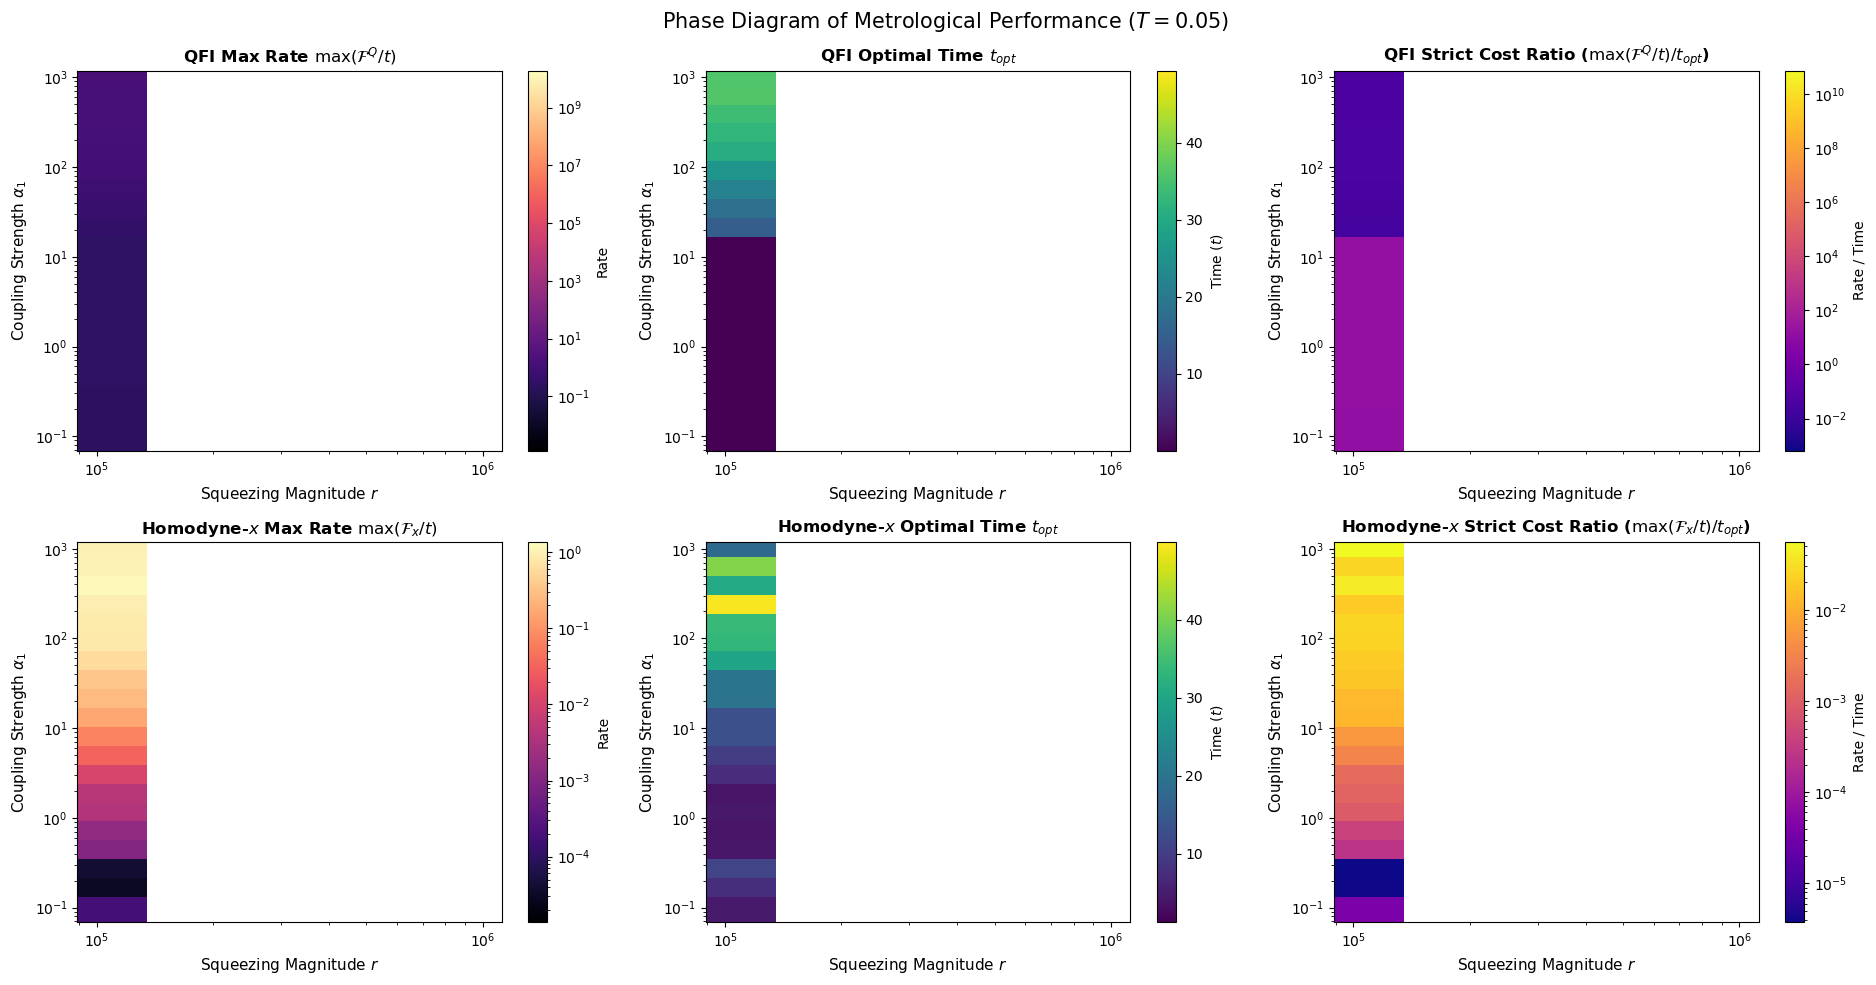

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm

def generate_sigma0(r, theta):
    """
    Generates the rotated squeezed covariance matrix.
    r: squeezing magnitude (r < 1 position squeezed, r > 1 momentum squeezed)
    theta: squeezing angle in radians
    """
    # Base squeezed state (diagonal)
    sigma_base = 0.5 * np.array([[r, 0], 
                                 [0, 1.0/r]])
    
    # Rotation matrix
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, s], 
                  [-s, c]])
    
    # Apply rotation: R * sigma_base * R^T
    sigma0 = R @ sigma_base @ R.T
    return sigma0


def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    dt = t_array[1] - t_array[0]
    N = len(t_array)
    
    G_r = G.real
    Gdot_r = Gdot.real
    Gddot_r = Gddot.real
    
    # System contribution to Covariance
    sx0, sp0, sxp0 = sigma0[0, 0], sigma0[1, 1], sigma0[0, 1]
    var_x_sys = (Gdot_r**2) * sx0 + (G_r / mass)**2 * sp0 + 2 * Gdot_r * (G_r / mass) * sxp0
    a, b = mass * Gddot_r, Gdot_r 
    var_p_sys = (a**2) * sx0 + (b**2) * sp0 + 2 * a * b * sxp0
    cov_xp_sys = Gdot_r * a * sx0 + (G_r/mass) * b * sp0 + (Gdot_r * b + (G_r/mass)*a)*sxp0

    # Precompute noise kernel and its Temperature derivative
    nu_grid = np.array([noise_kernel_residue(t, gamma, alpha1, alpha2, Temp) for t in t_array]) / mass
    dnu_grid = dnu_dT_residue(t_array, gamma, alpha1, alpha2, Temp) / mass 

    # Arrays to store tracking variables (Values and Rates)
    FI_het, FI_hom_x, FI_hom_p, QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    FI_rpd_ideal, FI_rpd_real = np.zeros(N), np.zeros(N)
    
    rate_het, rate_hom_x, rate_hom_p, rate_QFI = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    rate_rpd_ideal, rate_rpd_real = np.zeros(N), np.zeros(N)
    
    # Define Measurement Matrices
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]])
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]])
    
    def calc_classical_CFI(sig, dsig, sig_M):
        inv_term = np.linalg.inv(sig + sig_M)
        prod = np.dot(inv_term, dsig)
        return 0.5 * np.trace(np.dot(prod, prod))

    for i in tqdm(range(1, N), desc="Simulating Dynamics & FIs"):
        G_slice = G_r[:i+1][::-1] 
        Gd_slice = Gdot_r[:i+1][::-1] 
        nu_seg = nu_grid[:i+1]  
        dnu_seg = dnu_grid[:i+1]
        t_current = t_array[i]
        
        # Integrals (Toeplitz)
        yG = matmul_toeplitz((nu_seg, nu_seg), G_slice)
        yGd = matmul_toeplitz((nu_seg, nu_seg), Gd_slice)
        var_x_bath = np.dot(G_slice, yG) * dt**2
        var_p_bath = np.dot(Gd_slice, yGd) * dt**2
        cov_xp_bath = np.dot(G_slice, yGd) * dt**2
        
        sigma_t = np.array([
            [var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath],
            [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]
        ])
        
        dyG = matmul_toeplitz((dnu_seg, dnu_seg), G_slice)
        dyGd = matmul_toeplitz((dnu_seg, dnu_seg), Gd_slice)
        dvar_x_bath = np.dot(G_slice, dyG) * dt**2
        dvar_p_bath = np.dot(Gd_slice, dyGd) * dt**2
        dcov_xp_bath = np.dot(G_slice, dyGd) * dt**2
        
        dsigma_t = np.array([
            [dvar_x_bath, dcov_xp_bath],
            [dcov_xp_bath, dvar_p_bath]
        ])
        
        # 1. Classical FIs
        FI_het[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_t, dsigma_t, sig_M_hom_p)
        
        # --- 2. Photodetection FIs (Ideal & Realistic) ---
        A_rpd = sigma_t + sig_M_het
        det_A = np.linalg.det(A_rpd)
        inv_A = np.linalg.inv(A_rpd)
        trace_term = np.trace(np.dot(inv_A, dsigma_t))
        
        P_0_base = 1.0 / np.sqrt(det_A)
        
        # Ideal RPD (P_D = 0)
        dP_0_ideal = -0.5 * P_0_base * trace_term
        FI_rpd_ideal[i] = (dP_0_ideal**2) / (P_0_base * (1.0 - P_0_base) + 1e-15)
        
        # Realistic RPD (P_D = 0.02)
        P_0_real = (1.0 - 0.02) * P_0_base
        dP_0_real = -0.5 * P_0_real * trace_term
        FI_rpd_real[i] = (dP_0_real**2) / (P_0_real * (1.0 - P_0_real) + 1e-15)

        # --- 3. Quantum FI (Using Analytical Formula from Appendix B) ---
                
        # 3.a) Calculate determinants explicitly for 2x2 matrices
        det_sigma = sigma_t[0,0]*sigma_t[1,1] - sigma_t[0,1]**2
        det_dsigma = dsigma_t[0,0]*dsigma_t[1,1] - dsigma_t[0,1]**2
        
        # 3.b) Calculate the temperature derivative of the determinant (Eq. B15)
        d_det_sigma = dsigma_t[0,0]*sigma_t[1,1] + sigma_t[0,0]*dsigma_t[1,1] - 2*sigma_t[0,1]*dsigma_t[0,1]
        
        # 3.c) Apply Eq. (B20)
        # We use a tiny epsilon max-gate to prevent strict ZeroDivision at exactly t=0
        # since det_sigma approaches 0.25 for pure states.
        epsilon = 1e-16 
        purity_term = np.maximum(det_sigma - 0.25, epsilon)
        
        term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
        term2 = det_dsigma / (det_sigma + 0.25)
        
        QFI[i] = term1 - term2
        
        # 4. Calculate Rates directly
        
        rate_het[i] = FI_het[i] / t_current
        rate_hom_x[i] = FI_hom_x[i] / t_current
        rate_hom_p[i] = FI_hom_p[i] / t_current
        rate_rpd_ideal[i] = FI_rpd_ideal[i] / t_current
        rate_rpd_real[i] = FI_rpd_real[i] / t_current
        rate_QFI[i] = QFI[i] / t_current
        
    return {
        "time": t_array, 
        "rate_het": rate_het, "rate_hom_x": rate_hom_x, "rate_hom_p": rate_hom_p, 
        "rate_rpd_ideal": rate_rpd_ideal, "rate_rpd_real": rate_rpd_real, "rate_QFI": rate_QFI
    }

if __name__ == "__main__":
    # ==========================================
    # 1. PARAMETERS & GRID DEFINITION
    # ==========================================
    gamma = 1.0
    alpha2 = 2.0
    Omega_S_bare = 1.0
    temp = 0.05 
    mass = 1.0
    x0, p0 = 0.0, 0.0
    
    # --- TEST GRID (2x2) ---
    # To run the full grid overnight, change these to:
    # r_values = np.logspace(-3, 3, 50)
    # alpha1_values = np.logspace(-3, 1, 50)
    r_values = np.logspace(-5, 5, 20)
    alpha1_values = np.logspace(-1, 3, 20)
    
    num_r = len(r_values)
    num_alpha1 = len(alpha1_values)
    
    times = np.linspace(0, 50, 3000)
    
    # 2D Storage Arrays (Rows: alpha1, Columns: r)
    max_rate_QFI = np.zeros((num_alpha1, num_r))
    t_opt_QFI    = np.zeros((num_alpha1, num_r))
    
    max_rate_hom_x = np.zeros((num_alpha1, num_r))
    t_opt_hom_x    = np.zeros((num_alpha1, num_r))

    print(f"Starting 2D Grid Sweep ({num_alpha1}x{num_r})...")

    # ==========================================
    # 2. NESTED SWEEP (alpha1 Outer, r Inner)
    # ==========================================
    for i, alpha1 in enumerate(tqdm(alpha1_values, desc="alpha1 loop")):
        # Pre-compute bath dynamics ONCE per alpha1 (Outer Loop Optimization)
        delta_Omega_s = np.sqrt(alpha1)
        Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
        
        B = [1, gamma, alpha2 * gamma]
        A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
        
        info = inverse_laplace_rational(B, A)
        G, Gprime_of_t, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
        Gdot = Gprime_of_t
        
        for j, r in enumerate(r_values):
            # Diagonal state (theta = 0)
            sigma0 = 0.5 * np.array([[r, 0.0], 
                                     [0.0, 1.0/r]])
            
            # Evolve dynamics
            sol = evolve_all_FI_dynamics(times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass)
            valid_times = sol["time"][1:]
            
            # Extract QFI peaks
            t_opt_QFI[i, j], max_rate_QFI[i, j] = find_precise_peak(valid_times, sol["rate_QFI"][1:])
            
            # Extract Homodyne-x peaks
            t_opt_hom_x[i, j], max_rate_hom_x[i, j] = find_precise_peak(valid_times, sol["rate_hom_x"][1:])

    # ==========================================
    # 3. SAFETY SAVE TO DISK
    # ==========================================
    np.save("max_rate_QFI_grid.npy", max_rate_QFI)
    np.save("t_opt_QFI_grid.npy", t_opt_QFI)
    np.save("max_rate_hom_x_grid.npy", max_rate_hom_x)
    np.save("t_opt_hom_x_grid.npy", t_opt_hom_x)
    print("\nData successfully saved to disk! Generating plot...")

    # ==========================================
    # 4. HEATMAP VISUALIZATION (QFI & Homodyne-x)
    # ==========================================
    # Calculate the Ratio matrices
    ratio_QFI = max_rate_QFI / t_opt_QFI
    ratio_hom_x = max_rate_hom_x / t_opt_hom_x

    fig, axs = plt.subplots(2, 3, figsize=(19, 10))
    
    # Coordinate meshes for pcolormesh
    R_mesh, A1_mesh = np.meshgrid(r_values, alpha1_values)

    # --- TOP ROW: QUANTUM FISHER INFORMATION ---
    im00 = axs[0, 0].pcolormesh(R_mesh, A1_mesh, max_rate_QFI, norm=LogNorm(), cmap='magma', shading='nearest')
    axs[0, 0].set_title(r"QFI Max Rate $\max(\mathcal{F}^Q/t)$", fontsize=12, fontweight='bold')
    fig.colorbar(im00, ax=axs[0, 0], label="Rate")

    im01 = axs[0, 1].pcolormesh(R_mesh, A1_mesh, t_opt_QFI, cmap='viridis', shading='nearest')
    axs[0, 1].set_title(r"QFI Optimal Time $t_{opt}$", fontsize=12, fontweight='bold')
    fig.colorbar(im01, ax=axs[0, 1], label="Time ($t$)")

    im02 = axs[0, 2].pcolormesh(R_mesh, A1_mesh, ratio_QFI, norm=LogNorm(), cmap='plasma', shading='nearest')
    axs[0, 2].set_title(r"QFI Strict Cost Ratio ($\max(\mathcal{F}^Q/t) / t_{opt}$)", fontsize=12, fontweight='bold')
    fig.colorbar(im02, ax=axs[0, 2], label="Rate / Time")

    # --- BOTTOM ROW: HOMODYNE-X MEASUREMENT ---
    im10 = axs[1, 0].pcolormesh(R_mesh, A1_mesh, max_rate_hom_x, norm=LogNorm(), cmap='magma', shading='nearest')
    axs[1, 0].set_title(r"Homodyne-$x$ Max Rate $\max(\mathcal{F}_x/t)$", fontsize=12, fontweight='bold')
    fig.colorbar(im10, ax=axs[1, 0], label="Rate")

    im11 = axs[1, 1].pcolormesh(R_mesh, A1_mesh, t_opt_hom_x, cmap='viridis', shading='nearest')
    axs[1, 1].set_title(r"Homodyne-$x$ Optimal Time $t_{opt}$", fontsize=12, fontweight='bold')
    fig.colorbar(im11, ax=axs[1, 1], label="Time ($t$)")

    im12 = axs[1, 2].pcolormesh(R_mesh, A1_mesh, ratio_hom_x, norm=LogNorm(), cmap='plasma', shading='nearest')
    axs[1, 2].set_title(r"Homodyne-$x$ Strict Cost Ratio ($\max(\mathcal{F}_x/t) / t_{opt}$)", fontsize=12, fontweight='bold')
    fig.colorbar(im12, ax=axs[1, 2], label="Rate / Time")

    # Formatting axes across all subplots
    for ax in axs.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel("Squeezing Magnitude $r$", fontsize=11)
        ax.set_ylabel(r"Coupling Strength $\alpha_1$", fontsize=11)

    plt.suptitle(rf"Phase Diagram of Metrological Performance ($T={temp}$)", fontsize=15, y=0.98)
    plt.tight_layout()
    plt.show()